# Final Project
This shows the basic steps of SEP to detect objects in an image and perform some basic aperture photometry

### Importing required libraries


In [15]:
import numpy as np 
import sep 

In [16]:
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib import rcParams

%matplotlib inline

rcParams['figure.figsize'] = [10., 8.]

### Image Data

In [17]:
filename = 'hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits'
data = fits.getdata(filename)

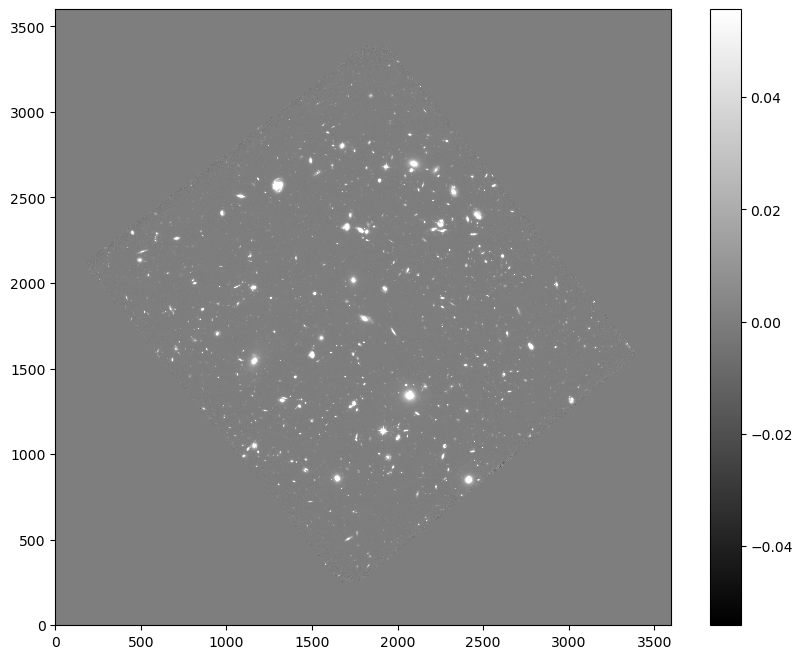

In [18]:
m, s = np.mean(data), np.std(data)
plt.imshow(data, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar();

### Background Subtraction 

In [19]:
data = data.astype(data.dtype.newbyteorder('='))

bkg = sep.Background(data)

In [20]:
print(bkg.globalback)
print(bkg.globalrms)

0.0
0.0005398219218477607


In [21]:
bkg_image = bkg.back()

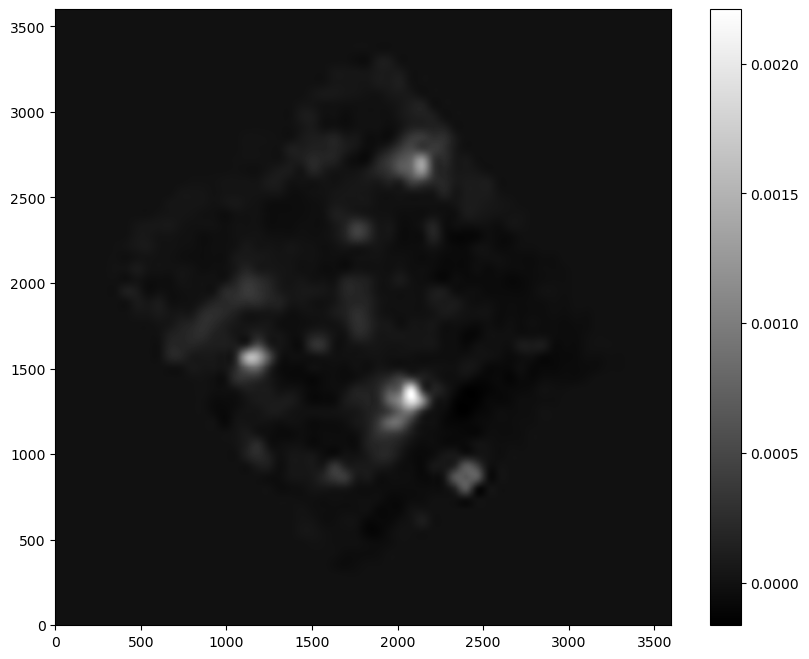

In [22]:
plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

In [23]:
bkg_rms = bkg.rms()

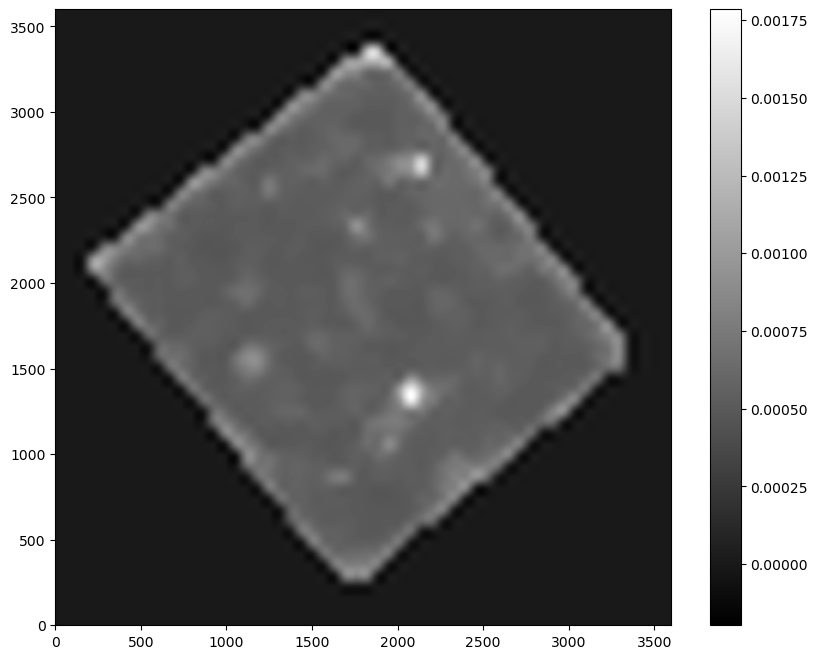

In [24]:
plt.imshow(bkg_rms, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

In [25]:
data_sub = data - bkg

### Object Detection 

In [26]:
objects = sep.extract(data_sub, 600, err=bkg.globalrms)

In [27]:
len(objects)

29

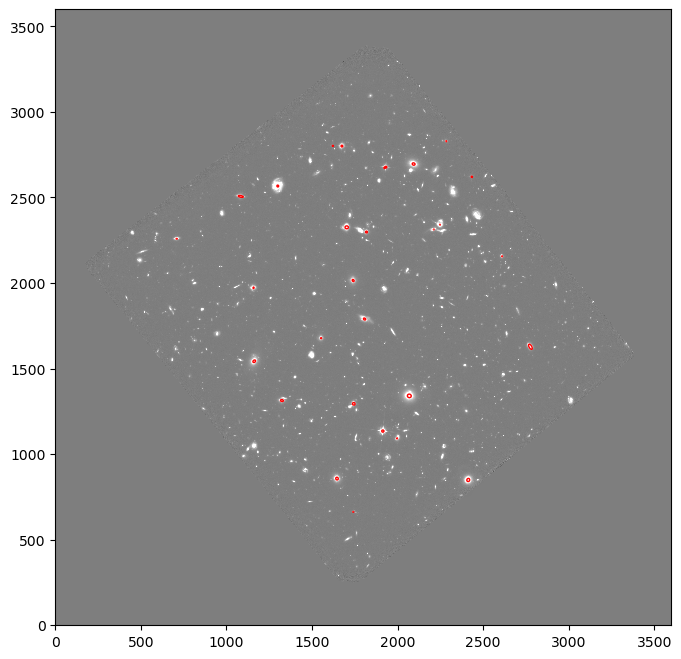

In [28]:
from matplotlib.patches import Ellipse

fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')

for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)

In [29]:
objects.dtype.names

('thresh',
 'npix',
 'tnpix',
 'xmin',
 'xmax',
 'ymin',
 'ymax',
 'x',
 'y',
 'x2',
 'y2',
 'xy',
 'errx2',
 'erry2',
 'errxy',
 'a',
 'b',
 'theta',
 'cxx',
 'cyy',
 'cxy',
 'cflux',
 'flux',
 'cpeak',
 'peak',
 'xcpeak',
 'ycpeak',
 'xpeak',
 'ypeak',
 'flag')

### Aperture photometry 

In [30]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'],
                                        3.0, err=bkg.globalrms, gain=1.0)

In [31]:
for i in range(10):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

object 0: flux = 8.185742 +/- 2.861075
object 1: flux = 65.613550 +/- 8.100220
object 2: flux = 72.429127 +/- 8.510531
object 3: flux = 8.873486 +/- 2.978841
object 4: flux = 806.091137 +/- 28.391744
object 5: flux = 51.928154 +/- 7.206120
object 6: flux = 45.628966 +/- 6.754922
object 7: flux = 77.809071 +/- 8.820945
object 8: flux = 56.597879 +/- 7.523157
object 9: flux = 24.471858 +/- 4.946905


# Final Answered Questions

### Analysis of Flux Values

Number of sources: 29


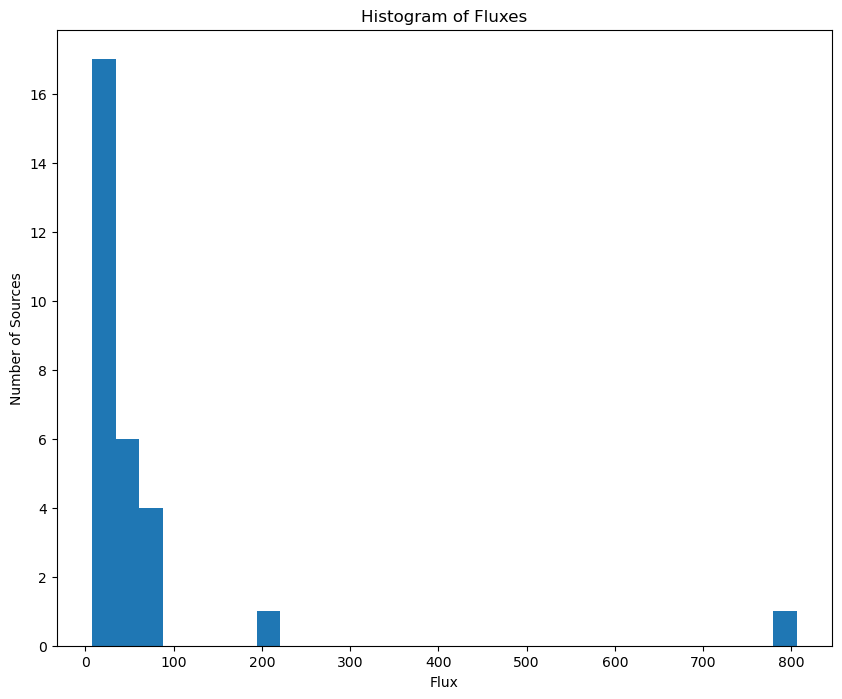

In [32]:
print("Number of sources:", len(flux))

plt.hist(flux, bins=30)
plt.xlabel("Flux")
plt.ylabel("Number of Sources")
plt.title("Histogram of Fluxes")
plt.show()

### Flux Statistics 

In [33]:
mean_flux = np.mean(flux)
median_flux = np.median(flux)
std_flux = np.std(flux)

print("Mean flux:", mean_flux)
print("Median flux:", median_flux)
print("Standard deviation:", std_flux)

Mean flux: 63.67473707363524
Median flux: 26.542590044736865
Standard deviation: 145.94958022986376


### Largest Outlier 

In [34]:
max_flux = np.max(flux)
z_score = (max_flux - mean_flux) / std_flux

print("Largest flux:", max_flux)
print("Standard deviations from mean:", z_score)

Largest flux: 806.0911373901366
Standard deviations from mean: 5.086800518009235
